เตรียมไลเบอรี

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [4]:
!mkdir -p images_dataset/train/good
!mkdir -p images_dataset/train/bad

In [19]:
!mkdir -p images_dataset/Test

In [5]:
import os
import glob

# ลบไฟล์ .jpg ทั้งหมดใน /content
files = glob.glob('/content/*.jpg')
for f in files:
    os.remove(f)

print("ลบรูปภาพทั้งหมดแล้ว")


ลบรูปภาพทั้งหมดแล้ว


โหลดข้อมูล พร้อมแบ่งข้อมูลเป็นสองส่วน train and test

In [10]:
#โหลดดาต้าเซ็ต
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. เตรียม Data Generator
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# 2. โหลดภาพแบบอัตโนมัติจากโฟลเดอร์ (train/valid แยกในตัว)
train_generator = train_datagen.flow_from_directory(
    "/content/images_dataset",     # <- ตรงนี้คือ path ของคุณ
    target_size=(224, 224),        # ขนาดภาพที่ input เข้าโมเดล
    batch_size=32,
    class_mode='binary',           # ถ้า good/bad ใช้ binary
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    "/content/images_dataset",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)


Found 84 images belonging to 1 classes.
Found 20 images belonging to 1 classes.


ลองตรวจสอขข้อมูล สิบอันดับ

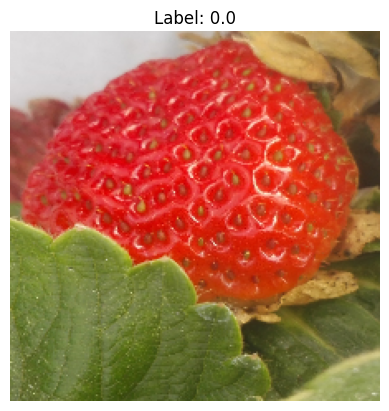

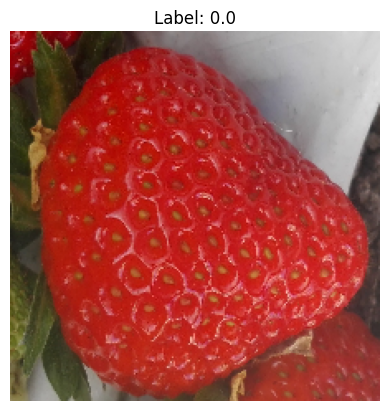

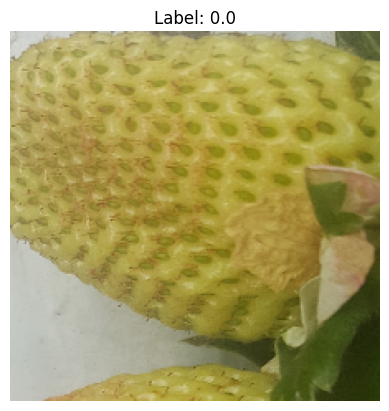

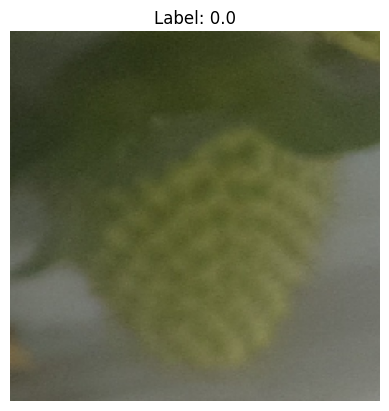

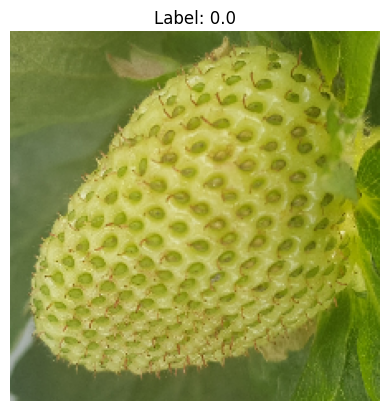

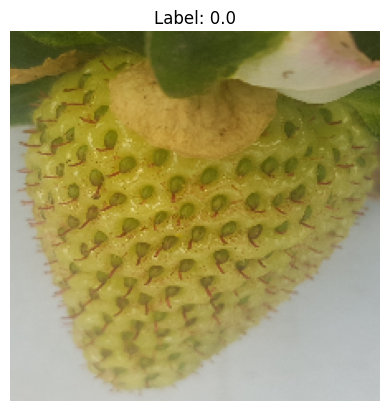

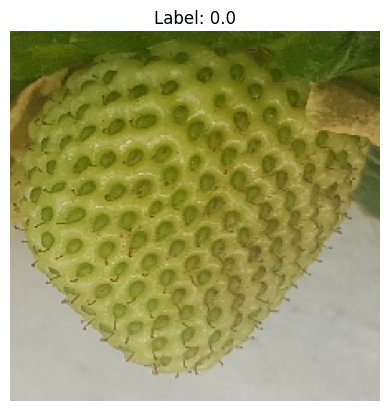

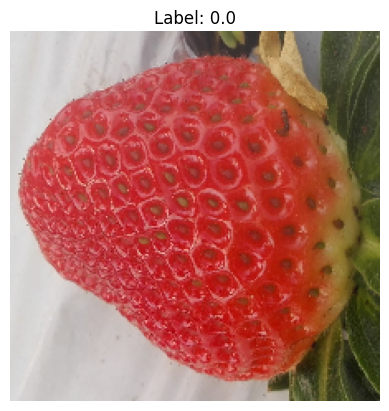

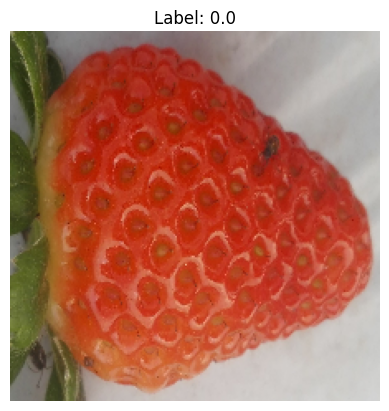

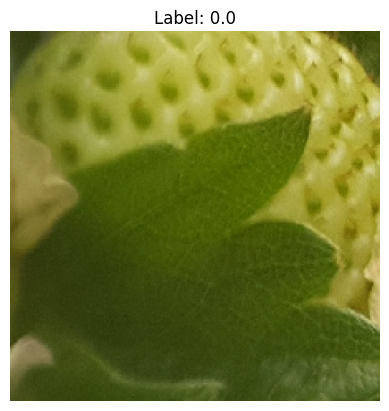

In [11]:
# แสดงภาพและ label จาก train_generator
import matplotlib.pyplot as plt

images, labels = next(train_generator)

for i in range(10):
    plt.imshow(images[i])
    plt.title(f"Label: {labels[i]}")
    plt.axis('off')
    plt.show()


สร้าง โมเดล classification

In [30]:
#Train model
# 2. โหลด MobileNetV2 (ไม่เอา top)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 3. Freeze weights เดิม
for layer in base_model.layers:
    layer.trainable = False

# 4. ต่อหัวใหม่ (หัว classification)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# 5. Compile
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

นำโมเดลที่ได้ไปทำนายข้อมูล

In [31]:
# Predict and evaluate
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.6168 - loss: 0.6626 - val_accuracy: 0.6500 - val_loss: 0.7085
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.5004 - loss: 0.7403 - val_accuracy: 0.6500 - val_loss: 0.6122
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - accuracy: 0.7469 - loss: 0.5562 - val_accuracy: 0.6500 - val_loss: 0.5710
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.7071 - loss: 0.5560 - val_accuracy: 0.8000 - val_loss: 0.5086
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.7261 - loss: 0.5527 - val_accuracy: 0.7500 - val_loss: 0.4934
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - accuracy: 0.7708 - loss: 0.5014 - val_accuracy: 0.7500 - val_loss: 0.4954
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.8744 - loss: 0.3492 - val_accuracy: 0.8000 - val_loss: 0.4190
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - accuracy: 0.9218 - loss: 0.3423 - val_accuracy: 0.8000 - val_loss: 0.4080
Epoch 9/10
3/3

ประเมินผลการทำงานโมเดล

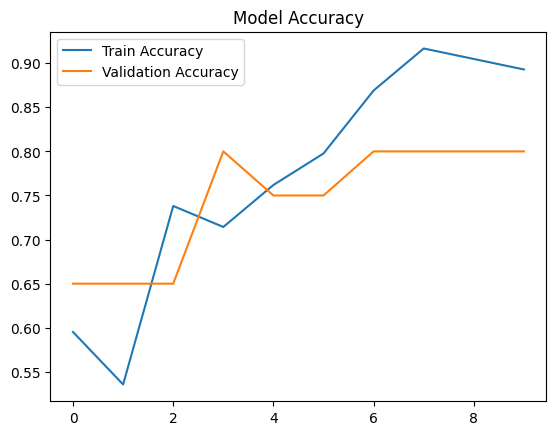

In [32]:
import matplotlib.pyplot as plt

# วาดกราฟ Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.legend()
plt.show()

นำโมเดลไปทำนายประโยคใหม่

In [33]:
from tensorflow.keras.preprocessing import image
import numpy as np

# โหลดภาพใหม่มาทดสอบ ตามตำแหน่งไฟล์
img_path = '/content/images_dataset/train/good/fresa_002.jpg'  # เปลี่ยน path ตามต้องการ
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# ทำนาย
pred = model.predict(img_array)

# แปลผล
print("Predicted Probability:", pred[0][0])
if pred[0][0] > 0.5:
    print("✅ ผลลัพธ์: เก็บได้ (good)")
else:
    print("❌ ผลลัพธ์: ยังไม่ได้ (bad)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Probability: 0.9557885
✅ ผลลัพธ์: เก็บได้ (good)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
สุ่มภาพ: fresa_342.jpg
ผลลัพธ์: ❌ ยังไม่ได้ (bad) (ความมั่นใจ: 0.3184)


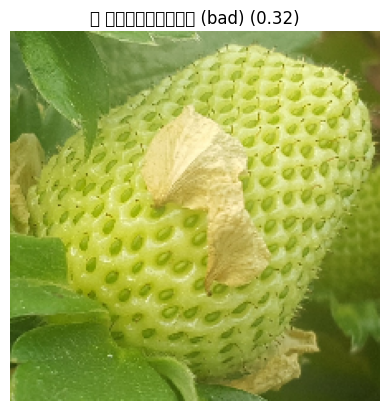

In [37]:
import os
import random
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# 🔹 ระบุโฟลเดอร์ที่เก็บภาพทดสอบ
test_folder = '/content/images_dataset/Test'

# 🔸 สุ่มชื่อไฟล์ภาพ 1 รูป
image_files = [f for f in os.listdir(test_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
random_file = random.choice(image_files)
img_path = os.path.join(test_folder, random_file)

# 🔹 โหลดและเตรียมภาพ
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# 🔹 ทำนาย
pred = model.predict(img_array)

# 🔹 แสดงผล
label = "✅ เก็บได้ (good)" if pred[0][0] > 0.5 else "❌ ยังไม่ได้ (bad)"
print(f"สุ่มภาพ: {random_file}")
print(f"ผลลัพธ์: {label} (ความมั่นใจ: {pred[0][0]:.4f})")

# 🔹 แสดงภาพประกอบ
plt.imshow(img)
plt.title(f"{label} ({pred[0][0]:.2f})")
plt.axis('off')
plt.show()
